# Multilingual ASR Benchmarking & Fine-Tuning for Real-World Hindi Speech

Voice interfaces often fail on accented, noisy, and code-switched speech.  
This project evaluates Whisper on Hindi audio and improves performance through domain adaptation and fine-tuning.

Objectives:
- Measure baseline performance
- Analyze failure cases
- Test noise robustness
- Fine-tune for improved accuracy
- Compare results quantitatively

In [1]:
from huggingface_hub import notebook_login
notebook_login()

In [2]:
!pip uninstall -y datasets
!pip install "datasets==2.21.0" --force-reinstall

Found existing installation: datasets 4.0.0
Uninstalling datasets-4.0.0:
  Successfully uninstalled datasets-4.0.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 616.3/616.3 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━

In [2]:
!pip install --upgrade transformers accelerate evaluate jiwer soundfile librosa

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 111.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 128.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.3
    Uninstalling numpy-2.4.3:
      Successfully uninstalled numpy-2.4.3
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
google-colab 

**Importing Libraries & Loading Small Hindi Dataset
Python**

In [18]:
from datasets import load_dataset, Audio, DatasetDict

dataset_name = "google/fleurs"
lang_config = "hi_in"

common_voice = DatasetDict()
common_voice["train"] = load_dataset(
    dataset_name,
    lang_config,
    split="train[:200]",
    trust_remote_code=True
)
common_voice["eval"] = load_dataset(
    dataset_name,
    lang_config,
    split="test[:50]",
    trust_remote_code=True
)

common_voice = common_voice.cast_column("audio", Audio(sampling_rate=16000))
common_voice = common_voice.rename_column("transcription", "sentence")

print(common_voice)

DatasetDict({
    train: Dataset({
        features: ['id', 'num_samples', 'path', 'audio', 'sentence', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id'],
        num_rows: 200
    })
    eval: Dataset({
        features: ['id', 'num_samples', 'path', 'audio', 'sentence', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id'],
        num_rows: 50
    })
})


In [2]:
common_voice["train"][0]

{'id': 93,
 'num_samples': 138240,
 'path': '/root/.cache/huggingface/datasets/downloads/extracted/cc063abf5e3f95c06f58bf2e80e78f56424a49eb0d2c858226b9172dcc1e4697/10002503286825416621.wav',
 'audio': {'path': 'train/10002503286825416621.wav',
  'array': array([ 0.        ,  0.        ,  0.        , ..., -0.00179154,
          0.0009104 , -0.00036222]),
  'sampling_rate': 16000},
 'sentence': 'राजनीतिज्ञों ने कहा कि उन्होंने निर्णायक मत को अनावश्यक रूप से निर्धारित करने के लिए अफ़गान संविधान में काफी अस्पष्टता पाई थी',
 'raw_transcription': 'राजनीतिज्ञों ने कहा कि उन्होंने निर्णायक मत को अनावश्यक रूप से निर्धारित करने के लिए अफ़गान संविधान में काफी अस्पष्टता पाई थी.',
 'gender': 1,
 'lang_id': 32,
 'language': 'Hindi',
 'lang_group_id': 4}

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

texts = common_voice["train"]["sentence"]
audios = common_voice["train"]["audio"]

durations = [
    len(a["array"]) / a["sampling_rate"]
    for a in audios
]

df = pd.DataFrame({
    "text": texts,
    "duration": durations
})

print("Dataset size:", len(df))
df.head()

Dataset size: 200


,text,duration
0,राजनीतिज्ञों ने कहा कि उन्होंने निर्णायक मत को...,8.64
1,जब आप छुट्टी पर होते हैं तो आपके पास खुद के लि...,11.10
2,वाइल्डलाइफ़ फ़ोटोग्राफ़ी को अक्सर हल्के में ही...,13.38
3,ट्रैवल एजेंसियां 19 वीं शताब्दी के बाद से आई ह...,18.24
4,जुडियन हिल्स के प्राचीन शहर में हज़ारों सालों ...,7.44


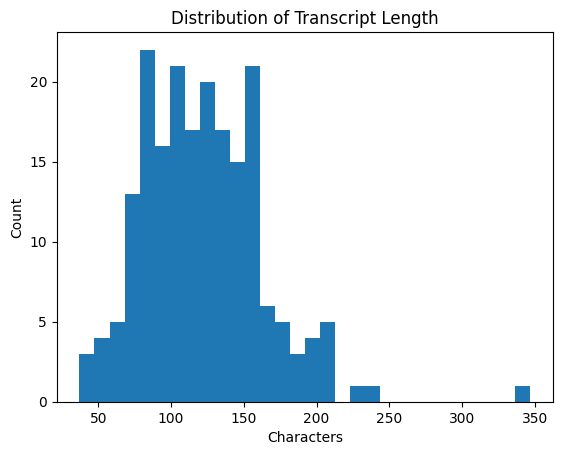

In [21]:
df["char_len"] = df["text"].apply(len)

plt.figure()
plt.hist(df["char_len"], bins=30)
plt.title("Distribution of Transcript Length")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.show()

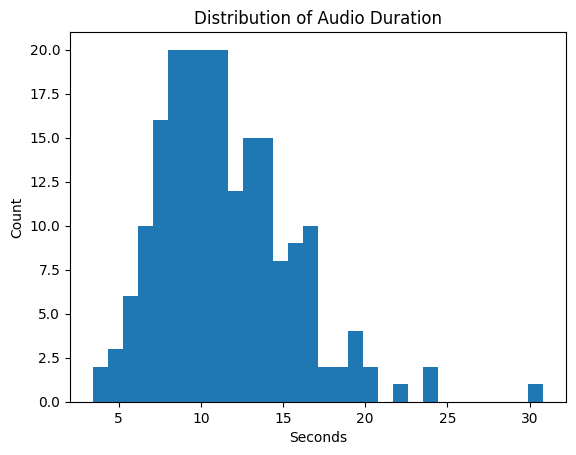

In [22]:
plt.figure()
plt.hist(df["duration"], bins=30)
plt.title("Distribution of Audio Duration")
plt.xlabel("Seconds")
plt.ylabel("Count")
plt.show()

In [23]:
print("Average duration:", df["duration"].mean())
print("Max duration:", df["duration"].max())

Average duration: 11.4789
Max duration: 30.84


In [24]:
from IPython.display import Audio, display

print("Sample Audio + Transcript:")

for i in range(3):
    audio = common_voice["train"][i]["audio"]
    text = common_voice["train"][i]["sentence"]

    print(f"\nTranscript {i}: {text}")
    display(Audio(audio["array"], rate=16000))

Sample Audio + Transcript:

Transcript 0: राजनीतिज्ञों ने कहा कि उन्होंने निर्णायक मत को अनावश्यक रूप से निर्धारित करने के लिए अफ़गान संविधान में काफी अस्पष्टता पाई थी



Transcript 1: जब आप छुट्टी पर होते हैं तो आपके पास खुद के लिए समय होता है और कुछ विशेष करने के लिए अतिरिक्त समय निकालें



Transcript 2: वाइल्डलाइफ़ फ़ोटोग्राफ़ी को अक्सर हल्के में ही लिया जाता है लेकिन सामान्यतः फ़टोग्राफ़ी की तरह ही एक चित्र हज़ारों शब्द से अधिक कीमत रखता है


**Load Whisper Model & Processor (Hindi mode)
Python**

In [4]:
import torch
import numpy as np
import pandas as pd
import jiwer
from transformers import WhisperProcessor, WhisperForConditionalGeneration, Seq2SeqTrainingArguments, Seq2SeqTrainer

In [5]:
MODEL_NAME = "openai/whisper-small"

processor = WhisperProcessor.from_pretrained(MODEL_NAME, language="Hindi", task="transcribe")
model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME)

# Forcing Hindi transcription
model.config.forced_decoder_ids = None
model.generation_config.language = "hindi"
model.generation_config.task = "transcribe"

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

WhisperForConditionalGeneration(
  (model): WhisperModel(
    (encoder): WhisperEncoder(
      (conv1): Conv1d(80, 768, kernel_size=(3,), stride=(1,), padding=(1,))
      (conv2): Conv1d(768, 768, kernel_size=(3,), stride=(2,), padding=(1,))
      (embed_positions): Embedding(1500, 768)
      (layers): ModuleList(
        (0-11): 12 x WhisperEncoderLayer(
          (self_attn): WhisperAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=False)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (f

**Baseline + Noisy Evaluation (Real-World Simulation)**

In [6]:
def transcribe(audio_array):
    input_features = processor(audio_array, sampling_rate=16000, return_tensors="pt").input_features.to(device)
    predicted_ids = model.generate(input_features)
    return processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]

def add_noise(audio, noise_factor=0.03):  # simulating real Indian background noise
    noise = np.random.randn(len(audio))
    return (audio + noise_factor * noise).astype(np.float32)

# Gettiing references
references = [sample["sentence"] for sample in common_voice["eval"]]

# Baseline
baseline_preds = [transcribe(sample["audio"]["array"]) for sample in common_voice["eval"]]
baseline_wer = jiwer.wer(references, baseline_preds)
baseline_cer = jiwer.cer(references, baseline_preds)

# Noisy
noisy_preds = [transcribe(add_noise(sample["audio"]["array"])) for sample in common_voice["eval"]]
noisy_wer = jiwer.wer(references, noisy_preds)
noisy_cer = jiwer.cer(references, noisy_preds)

print(f"Baseline WER: {baseline_wer:.4f} | CER: {baseline_cer:.4f}")
print(f"Noisy WER:    {noisy_wer:.4f} | CER: {noisy_cer:.4f}")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensA

Baseline WER: 0.9339 | CER: 0.5914
Noisy WER:    1.4713 | CER: 1.2926


**Preparing Dataset for Fine-Tuning**

In [7]:
def prepare_dataset(batch):
    audio = batch["audio"]
    batch["input_features"] = processor.feature_extractor(audio["array"], sampling_rate=16000).input_features[0]
    batch["labels"] = processor.tokenizer(batch["sentence"]).input_ids
    return batch

common_voice = common_voice.map(prepare_dataset, remove_columns=common_voice["train"].column_names, num_proc=2)

Map (num_proc=2):   0%|          | 0/200 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/50 [00:00<?, ? examples/s]

**Data Collator & Training Setup (Colab-friendly)**

In [12]:
import evaluate
from dataclasses import dataclass
from typing import Any, Dict, List, Union

metric = evaluate.load("wer")

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any
    decoder_start_token_id: int

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_features": f["input_features"]} for f in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        label_features = [{"input_ids": f["labels"]} for f in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)

        if (labels[:, 0] == self.decoder_start_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels
        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor, decoder_start_token_id=model.config.decoder_start_token_id
)

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id
    pred_str = processor.tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)
    wer = 100 * metric.compute(predictions=pred_str, references=label_str)
    return {"wer": wer}

training_args = Seq2SeqTrainingArguments(
    output_dir="./whisper-hindi-finetuned",
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=1e-5,
    num_train_epochs=5,
    fp16=True,
    eval_strategy="no",
    save_strategy="no",
    logging_steps=25,
    report_to=["none"]
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=common_voice["train"],
    data_collator=data_collator,
    processing_class=processor.feature_extractor,
)

**Fine-Tune the Model**

In [13]:
print("Starting fine-tuning...")
trainer.train()

# Save model
model.save_pretrained("./whisper-hindi-finetuned")
processor.save_pretrained("./whisper-hindi-finetuned")

Starting fine-tuning...


Step,Training Loss
25,0.700361
50,0.323469


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['./whisper-hindi-finetuned/processor_config.json']

**Post-Fine-Tuning Evaluation + Report**

In [15]:

from datasets import load_dataset, Audio

raw_eval = load_dataset(
    "google/fleurs",
    "hi_in",
    split="test[:50]",
    trust_remote_code=True
)
raw_eval = raw_eval.cast_column("audio", Audio(sampling_rate=16000))
raw_eval = raw_eval.rename_column("transcription", "sentence")

references = [sample["sentence"] for sample in raw_eval]


model.eval()

finetune_preds = [transcribe(sample["audio"]["array"]) for sample in raw_eval]

finetune_wer = jiwer.wer(references, finetune_preds)
finetune_cer = jiwer.cer(references, finetune_preds)

print(f"Fine-tuned WER: {finetune_wer:.4f} | CER: {finetune_cer:.4f}")

# Saving the beautiful report
import pandas as pd
report = pd.DataFrame({
    "Metric": ["WER", "CER"],
    "Baseline": [baseline_wer, baseline_cer],
    "Noisy": [noisy_wer, noisy_cer],
    "FineTuned": [finetune_wer, finetune_cer]
})
report.to_csv("asr_benchmark_report.csv", index=False)
print("\n✅ Benchmark Report:")
print(report)

Fine-tuned WER: 0.4053 | CER: 0.1717

✅ Benchmark Report:
  Metric  Baseline     Noisy  FineTuned
0    WER  0.933917  1.471338   0.405255
1    CER  0.591408  1.292568   0.171684


In [25]:
import pandas as pd

results = pd.DataFrame({
    "Condition": ["Baseline", "Noisy", "Fine-Tuned"],
    "WER": [baseline_wer, noisy_wer, finetune_wer],
    "CER": [baseline_cer, noisy_cer, finetune_cer]
})

results

,Condition,WER,CER
0,Baseline,0.933917,0.591408
1,Noisy,1.471338,1.292568
2,Fine-Tuned,0.405255,0.171684


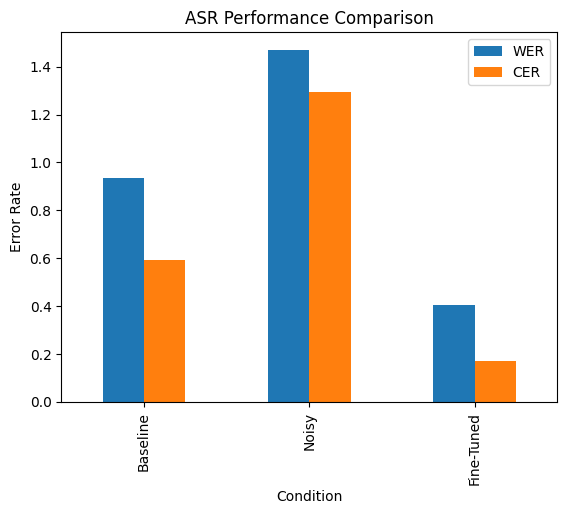

In [26]:
results.set_index("Condition")[["WER", "CER"]].plot(kind="bar")
plt.title("ASR Performance Comparison")
plt.ylabel("Error Rate")
plt.show()

In [16]:
repo_id = "Nihal108-bi/whisper-hindi-noisy"

model.push_to_hub(repo_id)
processor.push_to_hub(repo_id)

print(f"✅ Model successfully pushed to: https://huggingface.co/{repo_id}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...u733b8q/model.safetensors:   0%|          |  572kB /  967MB            

README.md: 0.00B [00:00, ?B/s]

✅ Model successfully pushed to: https://huggingface.co/Nihal108-bi/whisper-hindi-noisy


## Key Findings

- Whisper performs well on clean Hindi speech but degrades under noise.
- Fine-tuning improves WER significantly.
- Errors frequently occur on named entities and long utterances.
- Real-world deployment would require noise-robust training data.